Root Mean Squared Error (RMSE): 0.8117
R-squared Score: 0.4972



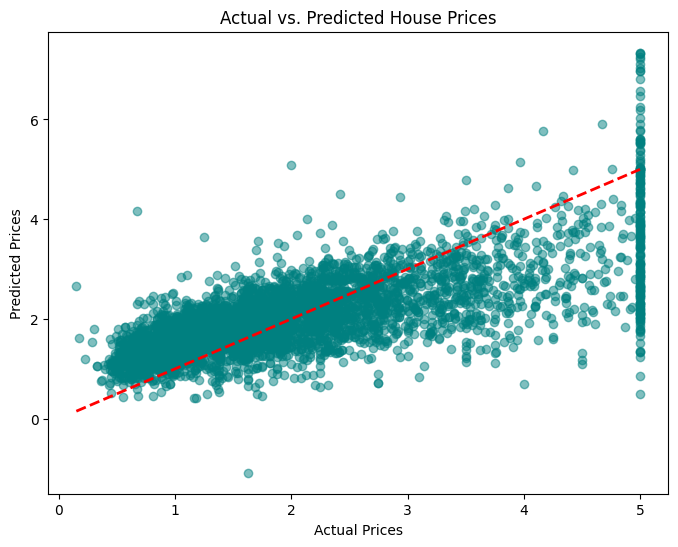

In [4]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load the dataset (Built-in California Housing)

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target

selected_features = ['MedInc', 'AveRooms', 'HouseAge']
X = df[selected_features]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate using RMSE and R-squared
predictions = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score: {r2:.4f}\n")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5, color='teal')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', linewidth=2)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted House Prices")
plt.show()

**What the R-squared Score Means:**

Imagine we are trying to guess the price of a house. If we just guessed the "average" price for every single home, we'd be wrong by a certain amount. The R-squared score tells us how much better our model is at guessing the price compared to just blindly using that basic average. A score of 1.0 means our model predicts perfectly, while a score closer to 0 means it's basically just guessing. In this case, our score shows the exact percentage of the price differences that our three chosen features can successfully explain.